In [1]:


try:
    import qiskit_aer
except:
    !pip3 install qiskit_aer
    import qiskit_aer

try:
    import pdflatex
except:
    !pip3 install pdflatex
    import pdflatex


try:
    import qiskit.visualization
except:
    !pip3 install 'qiskit[visualization]'
    import qiskit.visualization



In [2]:
# classical search

list_numbers = [1,3,4,2,6,5,7,9,8] 

def the_oracle(current_number):
    winner = 8
    if current_number is winner:
        return True
    else:
        return False

for index, current_number in enumerate(list_numbers):
    if the_oracle(current_number) is True:
        print('Winner found at index %i'%index)
        print('%i calls to the oracle used'%(index+1))

# you can see it takes O(n) time to find the winning number (assume the numbers of lsit are at random.. the winner could be at the end)
# using Groovers quantum search we can find the winner in O(sqrt(n)) time

Winner found at index 8
9 calls to the oracle used


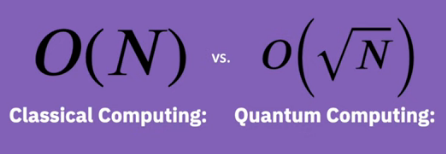

Oracle in quantum case which is blackbox flips the sign of winner.
If we use 2 qubits we can represent 4 inputs states. Let us say 11 is the inner. quantum_oracle(11) gives -11 ()

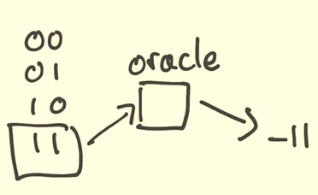

The states are changed using Unitary operator which is a gate in quantum circuit. The Oracle which flips the sign of winning number  can be implemented  by controlled-Z gate

We also need to do amplitude amplification which id done using Reflection

Grover's diffuciton operator = Oracle + Reflection





In [3]:
from qiskit import *
import matplotlib.pyplot as plt
import numpy as np

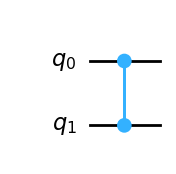

In [4]:
# define oracle circuit
oc = QuantumCircuit(2,name='oracle')
oc.cz(0,1)
oc.to_gate() # makes the circuit into its own gate
oc.draw('mpl', style="iqp")
# test oc - apply hadamard gate on both qubits - now oc will run 'oracle' function on all the uniformly superimposed state components parallely
# => it will run the oracle quantum function on |00> |01> |10> and |11> simultaneously




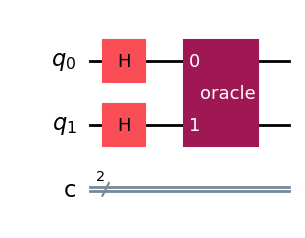

In [5]:
from qiskit_aer import Aer

backend = Aer.get_backend('statevector_simulator')
grover_circ = QuantumCircuit(2,2) # 2 qubits, 2 classical bits
grover_circ.h([0,1]) # hadamard gate on both the qubits
grover_circ.append(oc, [0,1]) # add oracle circuit to run on all components of superimposed state
grover_circ.draw('mpl', style="iqp")

In [6]:
#execute the job on simulator
from qiskit import transpile

new_circuit  = transpile(grover_circ, backend)
job  = backend.run(new_circuit )
result = job.result()

In [7]:
sv = result.get_statevector()
np.around(sv) # round the numbers
sv.draw('latex') # you will see that |11> got flipped to negative
# Normalize coefficients so that square  of cofficients all components add to 1 (so that probabilities are correct). 
# Since probabilities are square of coefficients the negative sign will never show up in any measurement




<IPython.core.display.Latex object>

With amplitude amplification we can amplify probability of winning state

winning state = |w> = 
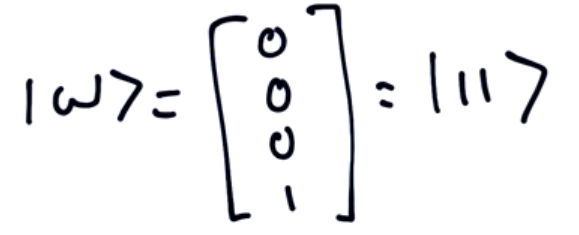

superposition state = |S> = 
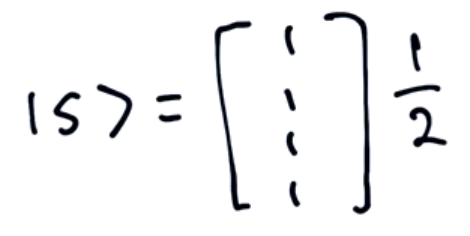

These 2 states are almost orthogonal

We define |S`> which  is actually orthogonal to |w> - this state has all other states except the winning state

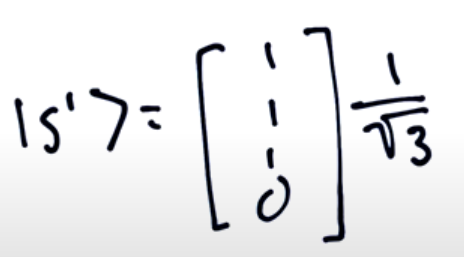

We can actually check w and s` are actually orthogonal to each other. s` is s state with w removed

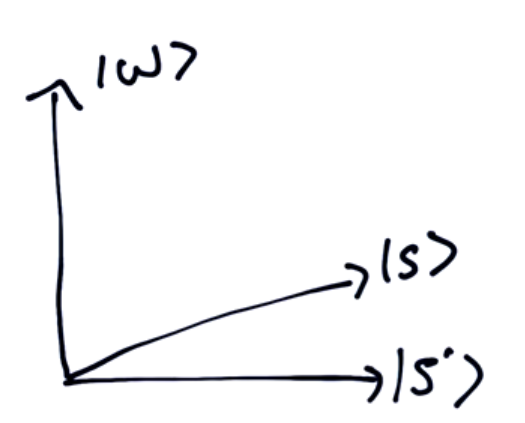


When we apply oracle circuit to |s> we are getting new state with flipped winning state

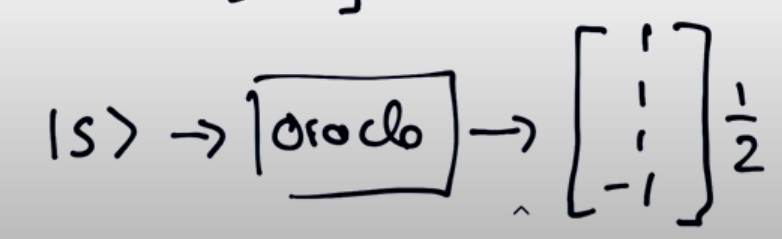

We can see that |s> got reflected over |s`> to get |s``>
 
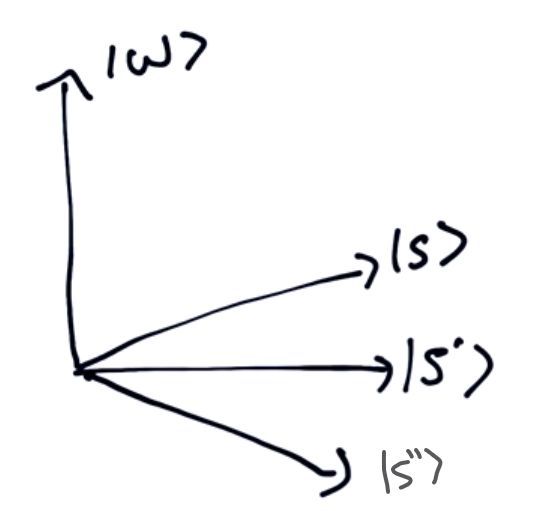


Now we again reflect |s``> over original |s> to |s```> ( using |s><s| - I )

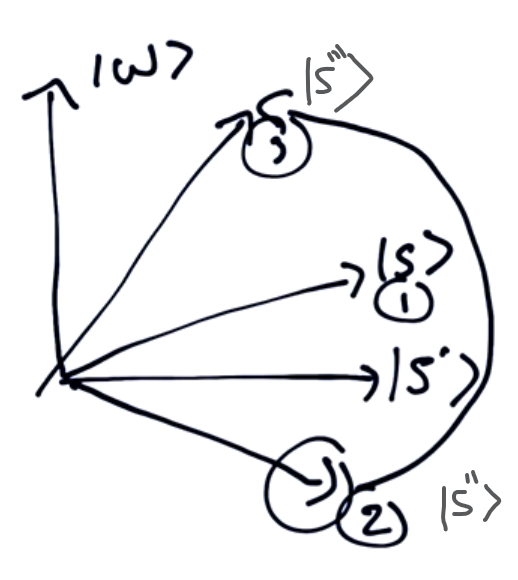

We see that quantum state has moved closer to winning vector (this is amplitude amplification). The number of times we have to amplify the amplitude will be O(sqrt(n))







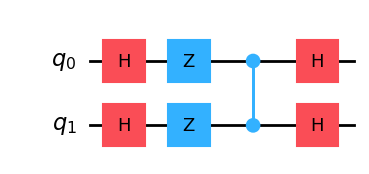

In [9]:
reflection = QuantumCircuit(2, name='reflection')

# we want to take superpoistion state back to L0 state (which can be done by applkying Hadamard on every qubit). Then apply a circuit that applies negative phase only to |00> state

reflection.h([0,1]) # apply hadamard gate on both qubits to bring them back to |0> state (note - Hadamard is itw own inverse operator)
reflection.z([0,1]) #  it is considered a Pauli-Z gate and can be visualized as a 180-degree rotation around the Z-axis in the Bloch sphere. it only affects the phase of the quantum state without altering the probability of measuring either 0 or 1 when in the computational basis
reflection.cz(0,1) # applies negative phase only to |00> state
reflection.h([0,1]) # transform to superposition state with Hadamard on both qubits
reflection.to_gate()

reflection.draw('mpl', style="iqp")

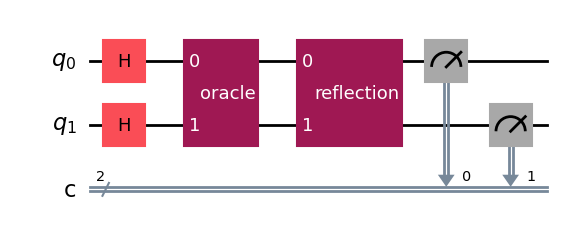

In [11]:
backend = Aer.get_backend('qasm_simulator')
grover_circ = QuantumCircuit(2,2)
grover_circ.h([0,1])
grover_circ.append(oc, [0,1])
grover_circ.append(reflection, [0,1])
grover_circ.measure([0,1],[0,1])
grover_circ.draw('mpl', style="iqp")

In [14]:
#execute the job on simulator
from qiskit import transpile

new_circuit  = transpile(grover_circ, backend) # since it is only 2 bit quantum circuit 1 shot is enough (sqrt(2))
job  = backend.run(new_circuit )
result = job.result()
result.get_counts() # you can see that result always has the winning '11' state (it gave 1024 times '11' state and no other state). We only used srt(n) calls to get to solution

{'11': 1024}